In [ ]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import fsps
from jax import jit
from tqdm import tqdm
from astropy import constants as const
tiny_number = 1e-70



In [31]:
from __future__ import annotations

import abc
from dataclasses import dataclass, field, replace
from typing import Any, Dict, Mapping, Sequence, Tuple

import jax
import jax.numpy as jnp
from jax import random

import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions

Array = jax.Array


@dataclass(frozen=True)
class Prior(abc.ABC):
    """
    JAX-friendly prior base class that delegates all probability operations to
    a TFP-JAX distribution. Subclasses must implement `tfp_dist()`.
    """

    alias: Dict[str, str] = field(init=False)
    params: Dict[str, Array] = field(init=False)
    name: str = ""

    def __init__(self,
                 parnames: Sequence[str] = (),
                 
                 name: str = "",
                 **kwargs: Any):

        prior_params: Tuple[str, ...] = getattr(type(self), "prior_params", None)
        if prior_params is None:
            raise ValueError(
                f"{type(self).__name__} must define class attribute "
                "`prior_params = (\"param1\", \"param2\", ...)`."
            )

        if not parnames:
            parnames = prior_params

        if len(parnames) != len(prior_params):
            raise ValueError(
                f"parnames has length {len(parnames)} but prior_params has "
                f"length {len(prior_params)}"
            )

        alias = dict(zip(prior_params, parnames))

        params: Dict[str, Array] = {}
        for intrinsic, external in alias.items():
            if external in kwargs:
                params[intrinsic] = jnp.asarray(kwargs[external])

        object.__setattr__(self, "alias", alias)
        object.__setattr__(self, "params", params)
        object.__setattr__(self, "name", name)

    # ------------------------------------------------------------------
    # Representation
    # ------------------------------------------------------------------
    def __repr__(self) -> str:
        argstring = [f"{k}={v}" for k, v in self.params.items()]
        return f"{type(self).__name__}({', '.join(argstring)})"

    def __len__(self) -> int:
        prior_params = getattr(type(self), "prior_params", ())
        if not prior_params:
            return 1
        return int(max(jnp.size(self.params.get(k, jnp.array(1.0)))
                       for k in prior_params))

    # ------------------------------------------------------------------
    # Pure functional parameter update (still jittable)
    # ------------------------------------------------------------------
    def update(self, **kwargs: Any) -> "Prior":
        if not kwargs:
            return self
        new_params = dict(self.params)
        for intrinsic, external in self.alias.items():
            if external in kwargs:
                new_params[intrinsic] = jnp.asarray(kwargs[external])
        return replace(self, params=new_params)

    # ------------------------------------------------------------------
    # Subclasses *must* provide a TFP distribution
    # ------------------------------------------------------------------
    @abc.abstractmethod
    def tfp_dist(self) -> tfd.Distribution:
        """
        Return a TFP-JAX distribution object built from `self.params`.

        Must be implemented by subclasses.
        """
        raise NotImplementedError

    # ------------------------------------------------------------------
    # Probability interface (delegates to TFP)
    # ------------------------------------------------------------------
    def logpdf(self, x: Array) -> Array:
        return self.tfp_dist().log_prob(x)

    def __call__(self, x: Array) -> Array:
        return self.logpdf(x)

    # ------------------------------------------------------------------
    # Sampling and transforms via TFP
    # ------------------------------------------------------------------
    def sample(self,
               key: jax.random.KeyArray,
               shape: Tuple[int, ...] | None = None) -> Array:
        if shape is None:
            shape = (len(self),)
        return self._sample_impl(key, shape)

    def _sample_impl(self, key: jax.random.KeyArray, shape: Tuple[int, ...]) -> Array:
        return self.tfp_dist().sample(seed=key, sample_shape=shape)

    def unit_transform(self, x: Array) -> Array:
        return self._ppf(x)

    def inverse_unit_transform(self, x: Array) -> Array:
        return self._cdf(x)

    def _ppf(self, x: Array) -> Array:
        return self.tfp_dist().quantile(x)

    def _cdf(self, x: Array) -> Array:
        return self.tfp_dist().cdf(x)

    # ------------------------------------------------------------------
    # Auto-diff gradient
    # ------------------------------------------------------------------
    def gradient(self, theta: Array) -> Array:
        def logp(t: Array) -> Array:
            return self(t).sum()
        return jax.grad(logp)(theta)

    # ------------------------------------------------------------------
    # Plotting helpers
    # ------------------------------------------------------------------
    @property
    @abc.abstractmethod
    def range(self) -> Tuple[Array, Array]:
        raise NotImplementedError

    @property
    @abc.abstractmethod
    def bounds(self) -> Tuple[Array, Array]:
        raise NotImplementedError

    @abc.abstractmethod
    def serialize(self) -> Mapping[str, Any]:
        raise NotImplementedError
    
    

In [32]:

#@dataclass(frozen=True)
class UniformPrior(Prior):
    """
    Uniform distribution on [low, high].
    """
    # Intrinsic parameter names:
    prior_params = ("low", "high")

    def tfp_dist(self) -> tfd.Distribution:
        low = self.params.get("low")
        high = self.params.get("high")
        return tfd.Uniform(low=low, high=high)

    @property
    def range(self):
        # Good plotting range is simply the interval itself
        return self.params["low"], self.params["high"]

    @property
    def bounds(self):
        # Hard support boundaries
        return self.params["low"], self.params["high"]

    def serialize(self):
        return {
            "type": "UniformPrior",
            "low": float(self.params["low"]),
            "high": float(self.params["high"]),
            "name": self.name,
        }

In [33]:
prior = UniformPrior()



In [34]:
import jax
import jax.numpy as jnp
from jax import random

# Instantiate prior: Uniform in [0, 5]
prior = UniformPrior(
    parnames=("low", "high"),  # external names
    low=0.0,
    high=5.0
)
# JIT-compiled sampler

@jax.jit
def sample_prior(key, nsamples: int):
    return prior.sample(key, shape=(nsamples,))

# Draw samples
key = random.PRNGKey(0)
samples = sample_prior(key, 20000)

TypeError: Non-shape-like value: Traced<ShapedArray(int32[1])>with<DynamicJaxprTrace> (type <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>)

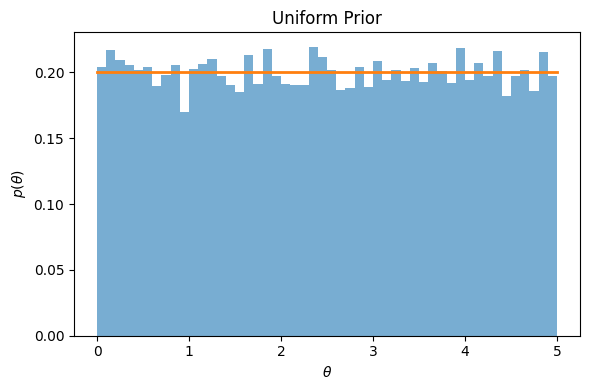

In [30]:
plt.figure(figsize=(6, 4))
plt.hist(samples, bins=50, density=True, alpha=0.6)

# Plot analytic PDF for comparison
low, high = prior.range
x = jnp.linspace(low, high, 200)
pdf = 1.0 / (high - low)

plt.plot(x, jnp.ones_like(x) * pdf, linewidth=2)
plt.xlabel(r"$\theta$")
plt.ylabel(r"$p(\theta)$")
plt.title("Uniform Prior")
plt.tight_layout()
plt.show()